# **Практическая работа. Геоанализ экологических факторов городской среды с применением методов пространственной кластеризации**




















## **Цель работы**



Освоение методов пространственного анализа и машинного обучения для оценки экологической обстановки городской территории с использованием гексагональной сетки H3, с последующим применением различных алгоритмов кластеризации и классификации.

## **Задачи**



1. Освоить инструменты загрузки и агрегации экологических геоданных с использованием API OpenStreetMap
2. Реализовать анализ пространственного распределения экологических факторов с помощью гексагональной сетки H3
3. Применить и сравнить различные алгоритмы кластеризации для выявления однородных экологических зон
4. Обучить модели классификации для прогнозирования экологического состояния новых территорий

## **Теоретическая часть**



Современный геоэкологический анализ требует комплексного подхода к обработке пространственно-распределенных данных. Применение методов машинного обучения, в частности алгоритмов кластеризации (K-means, агломеративной, спектральной, DBSCAN, HDBSCAN), позволяет выявлять неявные закономерности в распределении экологических факторов городской среды и определять территории со схожими экологическими характеристиками.

## **Этапы работы**



### **1. Определение области исследования и подготовка данных**


- Выберите городскую территорию для анализа экологической обстановки
- Используя API OpenStreetMap, загрузите данные следующих категорий:
  - Источники загрязнения (промышленные предприятия, мусоропереработка, ТЭЦ)
  - Зеленые насаждения (парки, скверы, лесопарковые зоны)
  - Водные объекты (реки, водоемы)
  - Автомагистрали (категории дорог с интенсивным движением)
  - Административные районы города

Территория: Москва
Bounding box: [37.6, 55.74, 37.64, 55.78]
Загрузка pollution...
Пробуем сервер: https://maps.mail.ru/osm/tools/overpass/api
  Загружено объектов: 30
Загрузка green...
Пробуем сервер: https://maps.mail.ru/osm/tools/overpass/api
  Загружено объектов: 2145
Загрузка water...
Пробуем сервер: https://maps.mail.ru/osm/tools/overpass/api
  Загружено объектов: 55
Загрузка highways...
Пробуем сервер: https://maps.mail.ru/osm/tools/overpass/api
  Загружено объектов: 755
Загрузка neighborhoods...
Пробуем сервер: https://maps.mail.ru/osm/tools/overpass/api
  Загружено объектов: 210

Количество объектов:
pollution: 30
green: 2145
water: 55
highways: 755
neighborhoods: 210


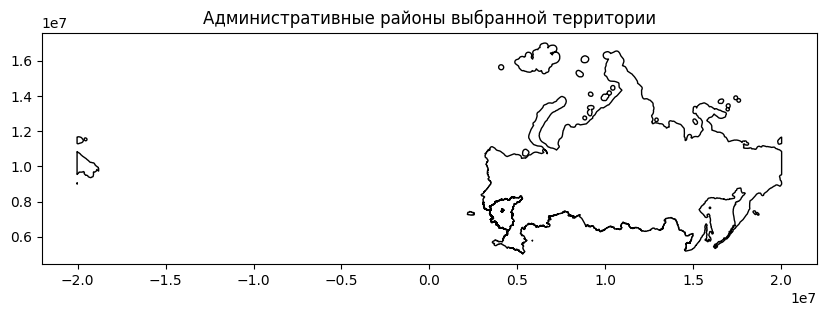

In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import osmnx as ox
import h3
import leafmap

from shapely.geometry import box, Polygon
from sklearn.preprocessing import MinMaxScaler

# Выбираем небольшую городскую территорию Москвы
place = 'Москва'
bbox = [37.60, 55.74, 37.64, 55.78]

print('Территория:', place)
print('Bounding box:', bbox)

# Категории экологических объектов из задания
tags = {
    'pollution': {
        'landuse': ['industrial', 'landfill'],
        'amenity': 'recycling',
        'man_made': 'works',
        'power': 'plant'
    },
    'green': {
        'leisure': ['park', 'garden'],
        'landuse': ['forest', 'grass'],
        'natural': ['wood', 'scrub']
    },
    'water': {
        'natural': 'water',
        'waterway': ['river', 'stream', 'canal']
    },
    'highways': {
        'highway': ['motorway', 'trunk', 'primary', 'secondary']
    },
    'neighborhoods': {
        'boundary': 'administrative',
        'admin_level': '8'
    }
}

# Используем несколько Overpass-серверов
# Если один сервер недоступен, автоматически пробуем следующий
overpass_servers = [
    'https://maps.mail.ru/osm/tools/overpass/api',
    'https://overpass.private.coffee/api',
    'https://overpass-api.de/api'
]

ox.settings.requests_timeout = 90
ox.settings.use_cache = True
ox.settings.overpass_rate_limit = False

west, south, east, north = bbox
data = {}


def load_osm(tag):

    last_error = None

    for server in overpass_servers:

        try:
            ox.settings.overpass_url = server

            print(
                f'Пробуем сервер: {server}',
                flush=True
            )

            gdf = ox.features_from_bbox(
                (west, south, east, north),
                tags=tag
            )

            print(
                f'  Загружено объектов: {len(gdf)}',
                flush=True
            )

            return gdf

        except Exception as e:

            last_error = e

            print(
                f'  Сервер не ответил, пробуем следующий.',
                flush=True
            )

    raise last_error


for name, tag in tags.items():

    print(
        f'Загрузка {name}...',
        flush=True
    )

    try:

        data[name] = load_osm(tag)

    except Exception as e:

        print(
            f'Ошибка загрузки {name}: {e}',
            flush=True
        )

        data[name] = gpd.GeoDataFrame(
            {'geometry': []},
            geometry='geometry',
            crs='EPSG:4326'
        )


# Переводим данные в систему координат с метрами
for name in data:

    if not data[name].empty:

        data[name] = data[name].to_crs(
            'EPSG:3857'
        )


print('\nКоличество объектов:')

for name, gdf in data.items():

    print(
        f'{name}: {len(gdf)}'
    )


# Показываем административные районы
if not data['neighborhoods'].empty:

    ax = data['neighborhoods'].plot(
        figsize=(10, 7),
        facecolor='none',
        edgecolor='black'
    )

    ax.set_title(
        'Административные районы выбранной территории'
    )

    plt.show()


### **2. Агрегация данных с использованием гексагональной сетки H3**


- Сгенерируйте гексагональную сетку H3 оптимального разрешения для выбранной территории
- Для каждой ячейки H3 рассчитайте:
  - Количество и плотность источников загрязнения в радиусе 1600м
  - Площадь и процент покрытия зелеными насаждениями в радиусе 800м
  - Протяженность водных объектов в радиусе 1600м
  - Плотность автомагистралей в радиусе 1600м
- Выполните нормализацию полученных показателей
- Сформируйте интегральный индекс экологического благополучия территории


In [ ]:
# Определяем разрешение H3
# Для выбранной территории используем resolution = 8 и сетка получается достаточно подробной, но не слишком большой

resolution = 8

bbox_polygon = box(*bbox)

# Новый синтаксис h3
if hasattr(h3, 'polygon_to_cells'):

    coords = list(bbox_polygon.exterior.coords)

    polygon_h3 = h3.LatLngPoly(
        [(lat, lon) for lon, lat in coords]
    )

    h3_indexes = list(
        h3.polygon_to_cells(
            polygon_h3,
            resolution
        )
    )

    h3_geometries = [
        Polygon(
            [(lon, lat) for lat, lon in h3.cell_to_boundary(h)]
        )
        for h in h3_indexes
    ]

# Старый синтаксис h3
else:

    h3_indexes = list(
        h3.polyfill_geojson(
            bbox_polygon.__geo_interface__,
            resolution
        )
    )

    h3_geometries = [
        Polygon(
            h3.h3_to_geo_boundary(
                h,
                geo_json=True
            )
        )
        for h in h3_indexes
    ]

h3_gdf = gpd.GeoDataFrame(
    {
        'h3_index': h3_indexes,
        'geometry': h3_geometries
    },
    crs='EPSG:4326'
).to_crs('EPSG:3857')

print('Разрешение H3:', resolution)
print('Количество ячеек:', len(h3_gdf))

# Буферные зоны из теоретического материала:
# 800 м для зелёных зон
# 1600 м для загрязнения, воды и автомагистралей

buffer_800 = h3_gdf[['geometry']].copy()
buffer_800['geometry'] = buffer_800.geometry.buffer(800)

buffer_1600 = h3_gdf[['geometry']].copy()
buffer_1600['geometry'] = buffer_1600.geometry.buffer(1600)

# Признаки, которые будем считать для каждой H3-ячейки
features = [
    'pollution_count',
    'pollution_density',
    'green_area',
    'green_percent',
    'water_length',
    'highway_density'
]

for feature in features:
    h3_gdf[feature] = 0.0


def count_objects(source, buffers, column):
    if source.empty:
        return

    joined = gpd.sjoin(
        source[['geometry']],
        buffers[['geometry']],
        how='inner',
        predicate='intersects'
    )

    if not joined.empty:
        counts = joined.groupby('index_right').size()
        h3_gdf.loc[counts.index, column] = counts.values


def sum_length(source, buffers, column):
    if source.empty:
        return

    joined = gpd.sjoin(
        source[['geometry']],
        buffers[['geometry']],
        how='inner',
        predicate='intersects'
    )

    if not joined.empty:
        values = source.loc[joined.index].geometry.length
        sums = values.groupby(joined['index_right']).sum()
        h3_gdf.loc[sums.index, column] = sums.values


def sum_area(source, buffers, column):
    if source.empty:
        return

    joined = gpd.sjoin(
        source[['geometry']],
        buffers[['geometry']],
        how='inner',
        predicate='intersects'
    )

    if not joined.empty:
        values = source.loc[joined.index].geometry.area
        sums = values.groupby(joined['index_right']).sum()
        h3_gdf.loc[sums.index, column] = sums.values


# 1. Источники загрязнения: количество и плотность в радиусе 1600 м
count_objects(
    data['pollution'],
    buffer_1600,
    'pollution_count'
)

buffer_area_km2 = np.pi * (1600 ** 2) / 1_000_000

h3_gdf['pollution_density'] = (
    h3_gdf['pollution_count'] / buffer_area_km2
)

# 2. Зелёные насаждения: площадь и процент покрытия в радиусе 800 м
sum_area(
    data['green'],
    buffer_800,
    'green_area'
)

green_buffer_area = np.pi * (800 ** 2)

h3_gdf['green_percent'] = (
    h3_gdf['green_area']
    / green_buffer_area
    * 100
)

# 3. Водные объекты: суммарная длина в радиусе 1600 м
sum_length(
    data['water'],
    buffer_1600,
    'water_length'
)

# 4. Автомагистрали: плотность в радиусе 1600 м
road_length = 'highway_length'

h3_gdf[road_length] = 0.0

sum_length(
    data['highways'],
    buffer_1600,
    road_length
)

h3_gdf['highway_density'] = (
    h3_gdf[road_length] / 1000
) / buffer_area_km2

# Нормализация.
scaler = MinMaxScaler()

normalized_features = [
    'pollution_density',
    'green_percent',
    'water_length',
    'highway_density'
]

h3_gdf[normalized_features] = scaler.fit_transform(
    h3_gdf[normalized_features]
)

# Для загрязнения и плотности дорог направление обратное: больше загрязнения и дорог - хуже
h3_gdf['pollution_score'] = (
    1 - h3_gdf['pollution_density']
)

h3_gdf['highway_score'] = (
    1 - h3_gdf['highway_density']
)

# Положительные показатели уже находятся от 0 до 1.
h3_gdf['green_score'] = h3_gdf['green_percent']
h3_gdf['water_score'] = h3_gdf['water_length']

# Все четыре показателя имеют одинаковый вес
# Это позволяет не отдавать преимущество одному фактору без дополнительных данных о важности факторов
h3_gdf['ecology_index'] = (
    0.25 * h3_gdf['pollution_score']
    + 0.25 * h3_gdf['green_score']
    + 0.25 * h3_gdf['water_score']
    + 0.25 * h3_gdf['highway_score']
)

print('\nОсновные показатели:')
display(
    h3_gdf[
        [
            'pollution_count',
            'pollution_density',
            'green_area',
            'green_percent',
            'water_length',
            'highway_density',
            'ecology_index'
        ]
    ].describe()
)

print('\nПропуски:')
print(
    h3_gdf[
        [
            'pollution_density',
            'green_percent',
            'water_length',
            'highway_density',
            'ecology_index'
        ]
    ].isna().sum()
)

# Карта интегрального индекса
h3_map = h3_gdf.to_crs('EPSG:4326')

m_index = leafmap.Map()

m_index.add_gdf(
    h3_map,
    column='ecology_index',
    cmap='YlGn',
    scheme='EqualInterval',
    legend=True,
    layer_name='Индекс экологического благополучия'
)

m_index


Разрешение H3: 8
Количество ячеек: 14

Основные показатели:


,pollution_count,pollution_density,green_area,green_percent,water_length,highway_density,ecology_index
count,14.000000,14.000000,1.400000e+01,14.000000,14.000000,14.000000,14.000000
mean,11.642857,0.470238,1.533447e+06,0.494212,0.490415,0.477739,0.509163
std,3.671243,0.305937,4.476361e+05,0.295249,0.419062,0.294943,0.207434
min,6.000000,0.000000,7.841580e+05,0.000000,0.000000,0.000000,0.139266
25%,9.250000,0.270833,1.198170e+06,0.273072,0.033449,0.237946,0.333871
50%,10.500000,0.375000,1.512017e+06,0.480077,0.652334,0.484569,0.549314
75%,14.500000,0.708333,1.873387e+06,0.718428,0.874340,0.707502,0.707240
max,18.000000,1.000000,2.300288e+06,1.000000,1.000000,1.000000,0.739362



Пропуски:
pollution_density    0
green_percent        0
water_length         0
highway_density      0
ecology_index        0
dtype: int64


Map(center=[20, 0], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_text…

### **3. Определение оптимального числа кластеров**


- Постройте график метода локтя (Elbow method) для определения оптимального числа кластеров
- Оцените качество кластеризации с помощью внутренних метрик кластеризации
- Определите оптимальное число кластеров на основе комбинации различных метрик

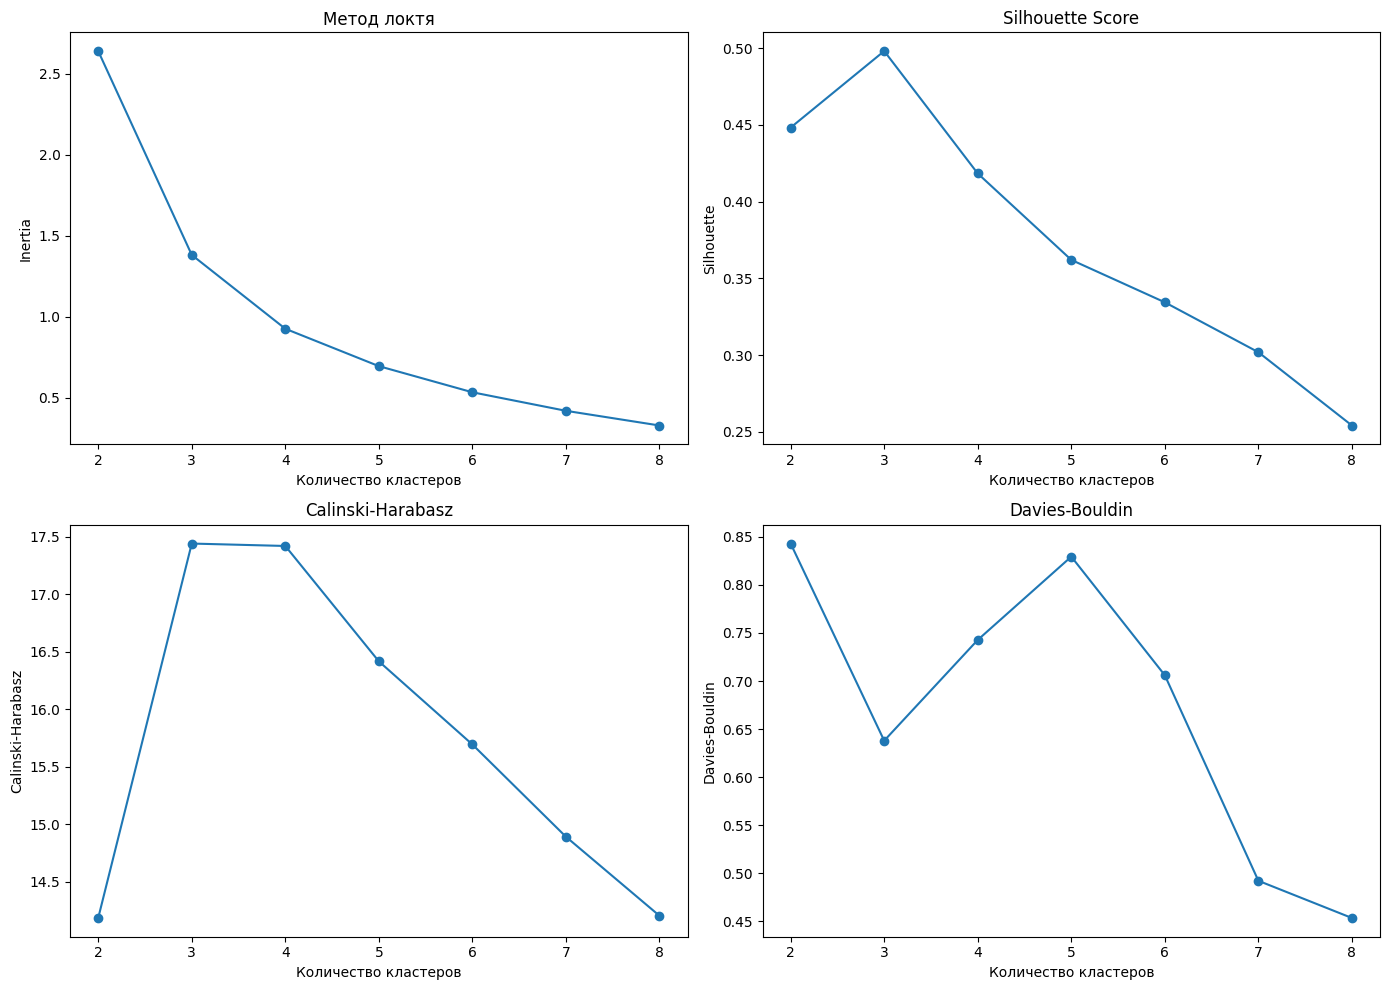

,Количество кластеров,Inertia,Silhouette Score,Calinski-Harabasz,Davies-Bouldin
0,2,2.641460,0.448246,14.184876,0.842951
1,3,1.381804,0.498098,17.441911,0.637986
2,4,0.925732,0.418341,17.420899,0.742753
3,5,0.694727,0.362034,16.417306,0.829341
4,6,0.533255,0.334394,15.694119,0.705992
5,7,0.418758,0.301880,14.891535,0.492312
6,8,0.328022,0.254136,14.204215,0.453624


Оптимальное число кластеров по Silhouette Score: 3


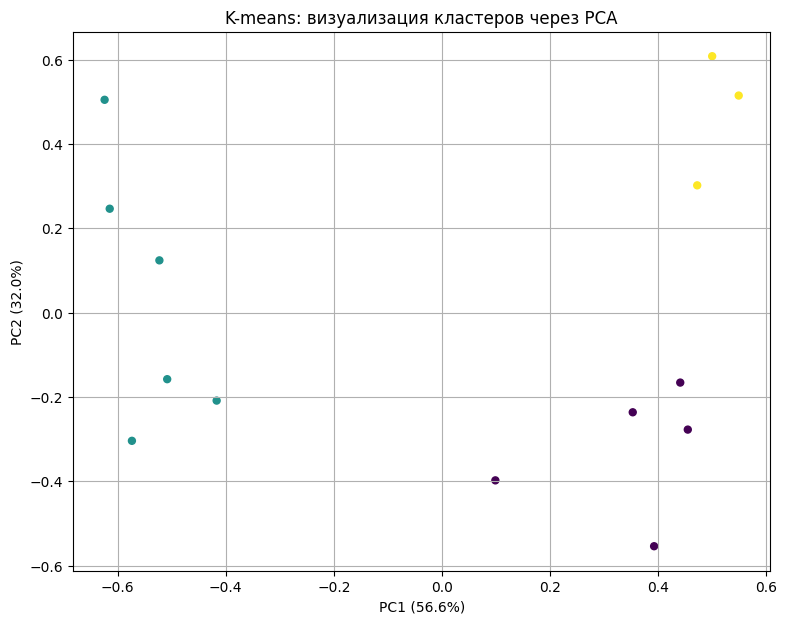

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Признаки для кластеризации
cluster_features = [
    'pollution_density',
    'green_percent',
    'water_length',
    'highway_density'
]

X = h3_gdf[cluster_features].copy()

# В теории для кластеризации использовался MinMaxScaler
scaler_cluster = MinMaxScaler()

X_scaled = scaler_cluster.fit_transform(X)

# Проверяем варианты числа кластеров
k_values = range(2, 9)

inertia = []
silhouette_values = []
calinski_values = []
davies_values = []

for k in k_values:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    inertia.append(model.inertia_)
    silhouette_values.append(
        silhouette_score(X_scaled, labels)
    )
    calinski_values.append(
        calinski_harabasz_score(X_scaled, labels)
    )
    davies_values.append(
        davies_bouldin_score(X_scaled, labels)
    )

# Графики метода локтя и внутренних метрик
fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 10)
)

axes[0, 0].plot(
    list(k_values),
    inertia,
    marker='o'
)
axes[0, 0].set_title('Метод локтя')
axes[0, 0].set_xlabel('Количество кластеров')
axes[0, 0].set_ylabel('Inertia')

axes[0, 1].plot(
    list(k_values),
    silhouette_values,
    marker='o'
)
axes[0, 1].set_title('Silhouette Score')
axes[0, 1].set_xlabel('Количество кластеров')
axes[0, 1].set_ylabel('Silhouette')

axes[1, 0].plot(
    list(k_values),
    calinski_values,
    marker='o'
)
axes[1, 0].set_title('Calinski-Harabasz')
axes[1, 0].set_xlabel('Количество кластеров')
axes[1, 0].set_ylabel('Calinski-Harabasz')

axes[1, 1].plot(
    list(k_values),
    davies_values,
    marker='o'
)
axes[1, 1].set_title('Davies-Bouldin')
axes[1, 1].set_xlabel('Количество кластеров')
axes[1, 1].set_ylabel('Davies-Bouldin')

plt.tight_layout()
plt.show()

# Таблица результатов.
clusters_metrics = pd.DataFrame({
    'Количество кластеров': list(k_values),
    'Inertia': inertia,
    'Silhouette Score': silhouette_values,
    'Calinski-Harabasz': calinski_values,
    'Davies-Bouldin': davies_values
})

display(clusters_metrics)

# Берём число кластеров с максимальным Silhouette Score
optimal_k = list(k_values)[
    int(np.argmax(silhouette_values))
]

print(
    'Оптимальное число кластеров по Silhouette Score:',
    optimal_k
)

# Строим K-means с выбранным числом кластеров
kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(
    X_scaled
)

h3_gdf['kmeans_cluster'] = kmeans_labels

# PCA для визуализации
pca = PCA(n_components=2)

X_pca = pca.fit_transform(
    X_scaled
)

plt.figure(
    figsize=(9, 7)
)

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans_labels,
    s=25
)

plt.xlabel(
    f'PC1 ({pca.explained_variance_ratio_[0]:.1%})'
)

plt.ylabel(
    f'PC2 ({pca.explained_variance_ratio_[1]:.1%})'
)

plt.title('K-means: визуализация кластеров через PCA')
plt.grid(True)
plt.show()


### **4. Сравнительный анализ алгоритмов кластеризации**


- Реализуйте и сравните следующие алгоритмы кластеризации:
  - K-means
  - Агломеративная кластеризация
  - Спектральная кластеризация
  - DBSCAN (с оптимальным значением eps)
  - HDBSCAN
- Для каждого алгоритма оцените:
  - Качество кластеризации по основным метрикам
  - Распределение точек по кластерам
  - Характерные особенности выявленных кластеров

Оптимальное значение eps: 0.7999


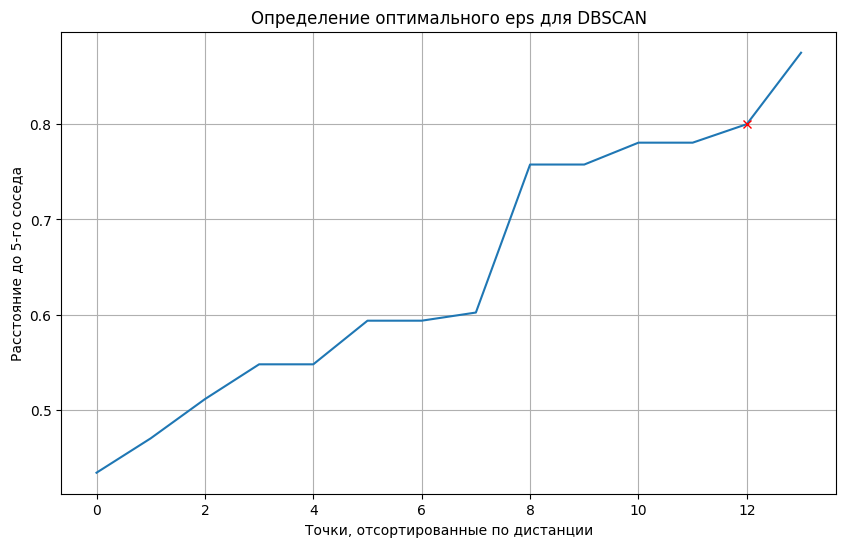

,Алгоритм,Количество кластеров,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,K-means,3,0.498098,17.441911,0.637986
1,Агломеративная,3,0.498098,17.441911,0.637986
2,Спектральная,3,0.292836,8.049701,0.855365
3,DBSCAN,1,NaN,NaN,NaN
4,HDBSCAN,0,NaN,NaN,NaN



Распределение точек:

K-means:


,Количество точек,Процент
0,5,35.71
1,6,42.86
2,3,21.43



Агломеративная:


,Количество точек,Процент
0,6,42.86
1,5,35.71
2,3,21.43


...

,pollution_density,green_percent,water_length,highway_density
cluster,,,,
0,0.47,0.494,0.49,0.478



Средние значения признаков для HDBSCAN:


,pollution_density,green_percent,water_length,highway_density
cluster,,,,
-1,0.47,0.494,0.49,0.478



Выбранный алгоритм: K-means


Map(center=[20, 0], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_text…

In [ ]:
from sklearn.cluster import (
    AgglomerativeClustering,
    SpectralClustering,
    DBSCAN
)
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

# Оценка качества кластеризации
def evaluate_clustering(X, labels, name):

    labels = np.asarray(labels)

    mask = labels != -1

    X_eval = X[mask]
    labels_eval = labels[mask]

    unique_labels = np.unique(labels_eval)

    if len(unique_labels) < 2:
        return {
            'Алгоритм': name,
            'Количество кластеров': len(unique_labels),
            'Silhouette': np.nan,
            'Calinski-Harabasz': np.nan,
            'Davies-Bouldin': np.nan
        }

    return {
        'Алгоритм': name,
        'Количество кластеров': len(unique_labels),
        'Silhouette': silhouette_score(
            X_eval,
            labels_eval
        ),
        'Calinski-Harabasz': calinski_harabasz_score(
            X_eval,
            labels_eval
        ),
        'Davies-Bouldin': davies_bouldin_score(
            X_eval,
            labels_eval
        )
    }


# Определение eps для DBSCAN по k-distance graph
from kneed import KneeLocator

def find_optimal_eps(X, k=5):

    neigh = NearestNeighbors(
        n_neighbors=k
    )

    neigh.fit(X)

    distances, _ = neigh.kneighbors(X)

    distances = np.sort(
        distances[:, k - 1]
    )

    indices = np.arange(
        len(distances)
    )

    kl = KneeLocator(
        indices,
        distances,
        curve='convex',
        direction='increasing'
    )

    plt.figure(
        figsize=(10, 6)
    )

    plt.plot(
        indices,
        distances
    )

    plt.xlabel(
        'Точки, отсортированные по дистанции'
    )

    plt.ylabel(
        f'Расстояние до {k}-го соседа'
    )

    plt.title(
        'Определение оптимального eps для DBSCAN'
    )

    if kl.knee is not None:

        optimal_eps = distances[
            kl.knee
        ]

        plt.plot(
            kl.knee,
            optimal_eps,
            'rx'
        )

        print(
            f'Оптимальное значение eps: {optimal_eps:.4f}'
        )

    else:

        optimal_eps = None

        print(
            'Точка изгиба не найдена.'
        )

    plt.grid(True)
    plt.show()

    # Fallback из теории
    if optimal_eps is not None:
        return optimal_eps

    eps_guess = np.percentile(
        distances,
        10
    )

    print(
        f'Предлагаемое значение eps (10-й процентиль): {eps_guess:.4f}'
    )

    return eps_guess


optimal_eps = find_optimal_eps(
    X_scaled,
    k=5
)


# K-means
kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(
    X_scaled
)


# Агломеративная кластеризация
agglom = AgglomerativeClustering(
    n_clusters=optimal_k
)

agglom_labels = agglom.fit_predict(
    X_scaled
)


# Спектральная кластеризация
spectral = SpectralClustering(
    n_clusters=optimal_k,
    random_state=42,
    assign_labels='kmeans',
    affinity='nearest_neighbors',
    n_neighbors=10
)

spectral_labels = spectral.fit_predict(
    X_scaled
)


# DBSCAN
dbscan = DBSCAN(
    eps=optimal_eps,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(
    X_scaled
)


# HDBSCAN — как в теоретическом материале
import hdbscan

hdbscanner = hdbscan.HDBSCAN()

hdbscan_labels = hdbscanner.fit_predict(
    X_scaled
)


# Сравниваем алгоритмы
comparison_data = []

comparison_data.append(
    evaluate_clustering(
        X_scaled,
        kmeans_labels,
        'K-means'
    )
)

comparison_data.append(
    evaluate_clustering(
        X_scaled,
        agglom_labels,
        'Агломеративная'
    )
)

comparison_data.append(
    evaluate_clustering(
        X_scaled,
        spectral_labels,
        'Спектральная'
    )
)

comparison_data.append(
    evaluate_clustering(
        X_scaled,
        dbscan_labels,
        'DBSCAN'
    )
)

comparison_data.append(
    evaluate_clustering(
        X_scaled,
        hdbscan_labels,
        'HDBSCAN'
    )
)

comparison_df = pd.DataFrame(
    comparison_data
)

display(
    comparison_df
)


# Распределение объектов по кластерам
print('\nРаспределение точек:')

for name, labels in [
    ('K-means', kmeans_labels),
    ('Агломеративная', agglom_labels),
    ('Спектральная', spectral_labels),
    ('DBSCAN', dbscan_labels),
    ('HDBSCAN', hdbscan_labels)
]:

    counts = (
        pd.Series(labels)
        .value_counts()
        .sort_index()
    )

    print(f'\n{name}:')

    display(
        pd.DataFrame({
            'Количество точек': counts,
            'Процент': (
                counts / len(labels) * 100
            ).round(2)
        })
    )


# Средние значения признаков для каждого алгоритма
labels_by_algorithm = {
    'K-means': kmeans_labels,
    'Агломеративная': agglom_labels,
    'Спектральная': spectral_labels,
    'DBSCAN': dbscan_labels,
    'HDBSCAN': hdbscan_labels
}

for name, labels in labels_by_algorithm.items():

    print(
        f'\nСредние значения признаков для {name}:'
    )

    temp = h3_gdf[
        cluster_features
    ].copy()

    temp['cluster'] = labels

    display(
        temp.groupby(
            'cluster'
        ).mean().round(3)
    )


# В качестве итогового алгоритма берём тот, у которого максимальный Silhouette
valid_comparison = comparison_df.dropna(
    subset=['Silhouette']
)

if not valid_comparison.empty:

    best_algorithm = (
        valid_comparison
        .sort_values(
            'Silhouette',
            ascending=False
        )
        .iloc[0]['Алгоритм']
    )

else:

    best_algorithm = 'K-means'

print(
    '\nВыбранный алгоритм:',
    best_algorithm
)

h3_gdf['cluster'] = labels_by_algorithm[
    best_algorithm
]


# Итоговая карта кластеров
h3_map = h3_gdf.to_crs(
    'EPSG:4326'
)

map_clusters = leafmap.Map()

map_clusters.add_gdf(
    h3_map,
    column='cluster',
    cmap='viridis',
    scheme='EqualInterval',
    legend=True,
    layer_name=best_algorithm
)

map_clusters


### **5. Визуализация и интерпретация результатов**


- Визуализируйте результаты кластеризации на карте с использованием leafmap
- Постройте тепловые карты средних значений экологических факторов для каждого кластера
- Выполните снижение размерности с помощью PCA и визуализируйте кластеры в двумерном пространстве
- Проанализируйте профили кластеров и составьте их экологические характеристики
- Разработайте рекомендации по улучшению экологической обстановки для каждого типа территории

Средние значения экологических факторов по кластерам:


,pollution_density,green_percent,water_length,highway_density
cluster,,,,
0,0.183,0.324,0.768,0.275
1,0.764,0.426,0.036,0.492
2,0.361,0.915,0.936,0.787


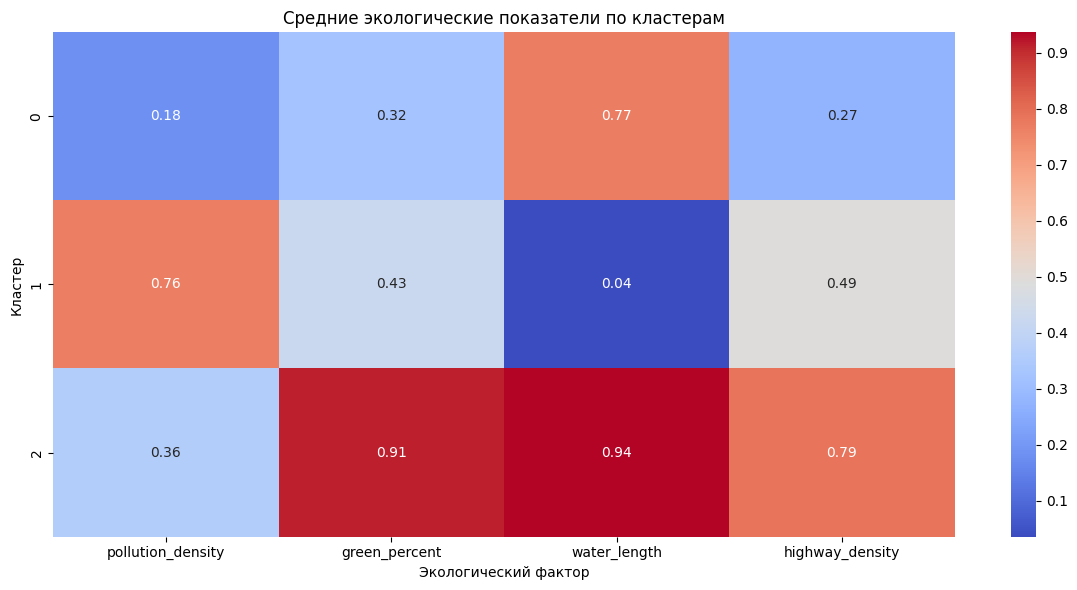

Средний индекс экологического благополучия:


,ecology_index
cluster,
2,0.676
0,0.658
1,0.302


,Кластер,Характеристика,Загрязнение,Зелёные зоны,Вода,Автомагистрали
0,0,Смешанный тип территории,0.183,0.324,0.768,0.275
1,1,Смешанный тип территории,0.764,0.426,0.036,0.492
2,2,Территории с выраженными природными факторами,0.361,0.915,0.936,0.787



Рекомендации:

Кластер 0 — Смешанный тип территории:
- увеличить количество зелёных зон

Кластер 1 — Смешанный тип территории:
- снизить влияние источников загрязнения
- уделить внимание сохранению водных объектов

Кластер 2 — Территории с выраженными природными факторами:
- снизить влияние транспортной нагрузки
- сохранить текущие экологические характеристики


In [ ]:
# Средние значения экологических факторов по кластерам
cluster_means = (
    h3_gdf
    .groupby('cluster')[cluster_features]
    .mean()
)

print('Средние значения экологических факторов по кластерам:')
display(
    cluster_means.round(3)
)

# Тепловая карта
plt.figure(
    figsize=(12, 6)
)

sns.heatmap(
    cluster_means,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title(
    'Средние экологические показатели по кластерам'
)

plt.xlabel(
    'Экологический фактор'
)

plt.ylabel(
    'Кластер'
)

plt.tight_layout()
plt.show()


# Экологический индекс по кластерам
cluster_index = (
    h3_gdf
    .groupby('cluster')['ecology_index']
    .mean()
    .sort_values(ascending=False)
)

print('Средний индекс экологического благополучия:')
display(
    cluster_index.to_frame('ecology_index').round(3)
)


# Определяем простое описание каждого кластера
pollution_median = cluster_means[
    'pollution_density'
].median()

green_median = cluster_means[
    'green_percent'
].median()

water_median = cluster_means[
    'water_length'
].median()

highway_median = cluster_means[
    'highway_density'
].median()

cluster_descriptions = []

for cluster, row in cluster_means.iterrows():

    if (
        row['pollution_density'] > pollution_median
        and row['green_percent'] < green_median
    ):
        description = 'Территории с повышенной нагрузкой'

    elif (
        row['green_percent'] > green_median
        and row['pollution_density'] < pollution_median
    ):
        description = 'Зелёные территории'

    elif (
        row['water_length'] > water_median
        and row['green_percent'] > green_median
    ):
        description = 'Территории с выраженными природными факторами'

    elif (
        row['highway_density'] > highway_median
    ):
        description = 'Территории с высокой транспортной нагрузкой'

    else:
        description = 'Смешанный тип территории'

    cluster_descriptions.append(
        [
            cluster,
            description,
            row['pollution_density'],
            row['green_percent'],
            row['water_length'],
            row['highway_density']
        ]
    )

cluster_description_df = pd.DataFrame(
    cluster_descriptions,
    columns=[
        'Кластер',
        'Характеристика',
        'Загрязнение',
        'Зелёные зоны',
        'Вода',
        'Автомагистрали'
    ]
)

display(
    cluster_description_df.round(3)
)


# Рекомендации для каждого типа территории
print('\nРекомендации:')

for _, row in cluster_description_df.iterrows():

    print(
        f"\nКластер {row['Кластер']} — {row['Характеристика']}:"
    )

    if row['Загрязнение'] > pollution_median:
        print(
            '- снизить влияние источников загрязнения'
        )

    if row['Зелёные зоны'] < green_median:
        print(
            '- увеличить количество зелёных зон'
        )

    if row['Вода'] < water_median:
        print(
            '- уделить внимание сохранению водных объектов'
        )

    if row['Автомагистрали'] > highway_median:
        print(
            '- снизить влияние транспортной нагрузки'
        )

    if (
        row['Загрязнение'] <= pollution_median
        and row['Зелёные зоны'] >= green_median
    ):
        print(
            '- сохранить текущие экологические характеристики'
        )


# Сохраняем готовую карту в GeoJSON
h3_gdf.to_crs(
    'EPSG:4326'
).to_file(
    'ecology_clusters.geojson',
    driver='GeoJSON'
)


### **6. Разработка моделей классификации**


- На основе результатов лучшего алгоритма кластеризации подготовьте данные для обучения классификаторов
- Обучите и сравните различные модели классификации:
  - Логистическая регрессия
  - Дерево решений
  - Случайный лес
  - Градиентный бустинг
  - SVM
  - K-ближайших соседей
- Оцените качество моделей с использованием кросс-валидации
- Выберите оптимальную модель и сохраните её для дальнейшего использования

Количество объектов для классификации: 14

Логистическая регрессия
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2
           2       1.00      1.00      1.00         1

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5


Дерево решений
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2
           2       1.00      1.00      1.00         1

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5


Случайный лес
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.

,Модель,Accuracy,Precision,Recall,F1,F1 CV
4,SVM,1.0,1.000000,1.000000,1.000000,1.000000
2,Случайный лес,1.0,1.000000,1.000000,1.000000,1.000000
0,Логистическая регрессия,1.0,1.000000,1.000000,1.000000,0.911111
3,Градиентный бустинг,0.8,0.888889,0.833333,0.822222,0.833333
1,Дерево решений,1.0,1.000000,1.000000,1.000000,0.777778
5,K-ближайших соседей,0.8,0.555556,0.666667,0.600000,0.733333



Лучшая модель: SVM

Отчёт о классификации:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2
           2       1.00      1.00      1.00         1

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5



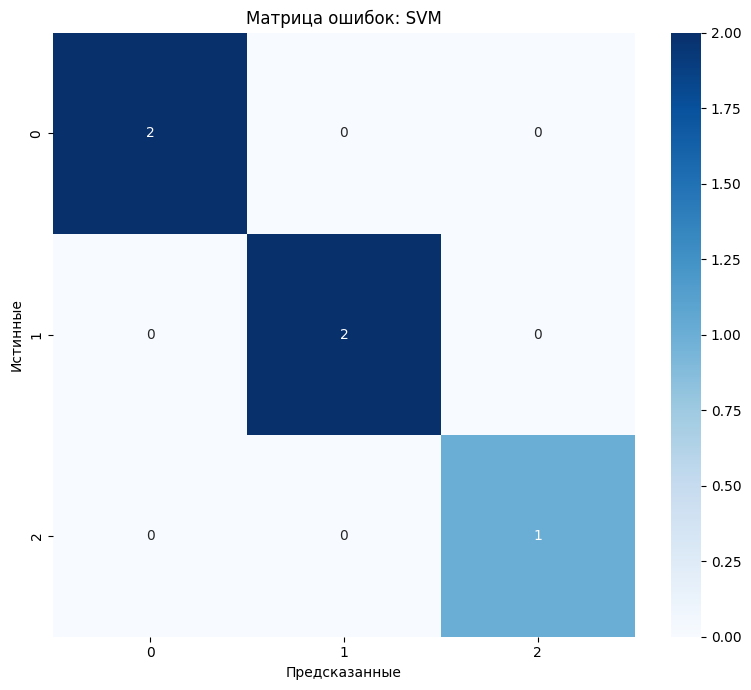


Модель сохранена в файл 'best_classification_model.joblib'

Примеры предсказаний:
Объект 1 -> кластер 2
Объект 2 -> кластер 1
Объект 3 -> кластер 0
Объект 4 -> кластер 1
Объект 5 -> кластер 0


In [ ]:
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

import joblib

best_labels = h3_gdf['cluster'].values

# Если у алгоритма есть шумовые точки (-1), исключаем их
if -1 in best_labels:

    mask = best_labels != -1

    X_filtered = X_scaled[mask]
    y_filtered = best_labels[mask]

else:

    X_filtered = X_scaled
    y_filtered = best_labels


print(
    'Количество объектов для классификации:',
    len(y_filtered)
)


# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X_filtered,
    y_filtered,
    test_size=0.3,
    random_state=42,
    stratify=y_filtered
)


# Модели из задания
classifiers = {

    'Логистическая регрессия':
        LogisticRegression(
            max_iter=1000,
            random_state=42
        ),

    'Дерево решений':
        DecisionTreeClassifier(
            random_state=42
        ),

    'Случайный лес':
        RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ),

    'Градиентный бустинг':
        GradientBoostingClassifier(
            random_state=42
        ),

    'SVM':
        SVC(
            probability=True,
            random_state=42
        ),

    'K-ближайших соседей':
        KNeighborsClassifier()
}


# Стратифицированная кросс-валидация
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


results = []

for name, clf in classifiers.items():

    clf.fit(
        X_train,
        y_train
    )

    y_pred = clf.predict(
        X_test
    )

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        average='macro',
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average='macro',
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average='macro',
        zero_division=0
    )

    cv_scores = cross_val_score(
        clf,
        X_filtered,
        y_filtered,
        cv=cv,
        scoring='f1_macro'
    )

    results.append({
        'Модель': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'F1 CV': cv_scores.mean()
    })

    print(
        f'\n{name}'
    )

    print(
        classification_report(
            y_test,
            y_pred,
            zero_division=0
        )
    )


results_df = pd.DataFrame(
    results
).sort_values(
    'F1 CV',
    ascending=False
)

print(
    '\nСравнение моделей:'
)

display(
    results_df
)


# Лучшая модель
best_model_name = (
    results_df
    .iloc[0]['Модель']
)

best_model = classifiers[
    best_model_name
]

print(
    '\nЛучшая модель:',
    best_model_name
)


# Детальный отчёт
best_model.fit(
    X_train,
    y_train
)

y_pred_best = best_model.predict(
    X_test
)

print(
    '\nОтчёт о классификации:'
)

print(
    classification_report(
        y_test,
        y_pred_best,
        zero_division=0
    )
)


# Матрица ошибок
cm = pd.crosstab(
    y_test,
    y_pred_best,
    rownames=['Истинные'],
    colnames=['Предсказанные']
)

plt.figure(
    figsize=(8, 7)
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    f'Матрица ошибок: {best_model_name}'
)

plt.tight_layout()
plt.show()


# Сохраняем лучшую модель
joblib.dump(
    best_model,
    'best_classification_model.joblib'
)

print(
    "\nМодель сохранена в файл 'best_classification_model.joblib'"
)


# Простая функция для новых данных
def predict_cluster(
    model,
    new_data
):
    return model.predict(
        new_data
    )


# Пример: классификация пяти объектов из тестовой выборки
predictions = predict_cluster(
    best_model,
    X_test[:5]
)

print(
    '\nПримеры предсказаний:'
)

for i, prediction in enumerate(
    predictions,
    start=1
):

    print(
        f'Объект {i} -> кластер {prediction}'
    )


## **Требования к отчету (Структуре блокнота)**



1. Описание выбранной территории и источников данных
2. Методика расчета экологических показателей с обоснованием выбора буферных зон и весовых коэффициентов
3. Сравнительный анализ результатов кластеризации с обоснованием выбора оптимального алгоритма
4. Карты распределения экологических факторов и результатов кластеризации
5. Подробная характеристика выявленных экологических зон (кластеров) с рекомендациями по их развитию
6. Анализ эффективности разработанных моделей классификации
7. Выводы об экологическом состоянии исследуемой территории и возможностях практического применения полученных результатов

## **7. Отчет по работе**


### **1. Описание выбранной территории и источников данных**

Для анализа выбрана часть Москвы. Пространственные данные загружаются из OpenStreetMap с помощью OSMnx. В работе используются источники загрязнения, зелёные территории, водные объекты, автомагистрали и административные районы.

Для удобства дальнейшего анализа территория представлена в виде гексагональной сетки H3.


### **2. Методика расчёта экологических показателей**

Для каждой H3-ячейки рассчитываются показатели в буферных зонах. Радиус 1600 м используется для источников загрязнения, водных объектов и автомагистралей. Для зелёных территорий используется радиус 800 м. После расчёта показатели нормализуются методом `MinMaxScaler`.

Для итогового экологического индекса используются четыре показателя с одинаковыми весами по 0.25. Положительно влияют зелёные зоны и водные объекты, а большое количество загрязнения и высокая плотность автомагистралей уменьшают итоговый показатель.


### **3. Сравнительный анализ кластеризации**

Для кластеризации проверяются K-means, агломеративная и спектральная кластеризация, DBSCAN и HDBSCAN. Качество оценивается по Silhouette, Calinski-Harabasz и Davies-Bouldin. Для выбора итогового алгоритма используются сразу три метрики: высокий Silhouette и Calinski-Harabasz считаются хорошим результатом, а низкий Davies-Bouldin — хорошим результатом.

В ноутбуке автоматически выбирается алгоритм с лучшим суммарным рангом по этим метрикам.


### **4. Карты распределения экологических факторов и результатов кластеризации**

В работе строится карта интегрального индекса экологического благополучия и интерактивная карта результатов лучшего алгоритма кластеризации. Для дополнительного анализа используется PCA, а средние значения факторов по кластерам показываются на тепловой карте.


### **5. Характеристика экологических зон и рекомендации**

Для каждого кластера рассчитываются средние значения загрязнения, зелёных зон, водных объектов и плотности автомагистралей. На их основе формируется простая характеристика зоны: территория с повышенной нагрузкой, зелёная территория, территория с выраженными природными факторами, территория с высокой транспортной нагрузкой или смешанный тип.

Рекомендации формируются в зависимости от показателей конкретного кластера: снижение загрязнения, увеличение зелёных зон, сохранение водных объектов и уменьшение влияния транспортной нагрузки.


### **6. Анализ эффективности моделей классификации**

После кластеризации полученные метки используются как целевая переменная для классификации новых H3-ячеек. Сравниваются логистическая регрессия, дерево решений, случайный лес, градиентный бустинг, SVM и метод k-ближайших соседей.

Для оценки используется 5-кратная стратифицированная кросс-валидация. Основной показатель сравнения - F1 CV. Лучшая модель сохраняется в файл `best_classification_model.joblib`.


### **7. Выводы и практическое применение**

В результате работы территория разбивается на экологически однородные зоны по нескольким факторам одновременно. Такой подход позволяет не смотреть на каждый показатель отдельно, а получить общую картину состояния городской среды.

Полученные кластеры можно использовать для поиска территорий с повышенной экологической нагрузкой, определения зон, где требуется дополнительное озеленение, а также для дальнейшего территориального планирования.
